In [8]:
import sys
!{sys.executable} -m pip install regex nltk textblob

In [2]:
from textblob import TextBlob
text = 'Today is a beautiful day.'
blob = TextBlob(text)
blob

TextBlob("Today is a beautiful day.")

In [14]:
blob.sentences

[Sentence("Today is a beautiful day.")]

In [15]:
blob.words

WordList(['Today', 'is', 'a', 'beautiful', 'day'])

In [16]:
blob.tags

[('Today', 'NN'),
 ('is', 'VBZ'),
 ('a', 'DT'),
 ('beautiful', 'JJ'),
 ('day', 'NN')]

In [17]:
blob.noun_phrases

WordList(['beautiful day'])

In [18]:
blob.sentiment

Sentiment(polarity=0.85, subjectivity=1.0)

In [19]:
%precision 3

'%.3f'

In [20]:
blob.sentiment.polarity

0.850

In [21]:
blob.sentiment.subjectivity

1.000

In [22]:
from textblob.sentiments import NaiveBayesAnalyzer
blob = TextBlob(text,analyzer=NaiveBayesAnalyzer())
blob

TextBlob("Today is a beautiful day.")

In [23]:
blob.sentiment

Sentiment(classification='pos', p_pos=0.8117563121751951, p_neg=0.18824368782480477)

In [24]:
from textblob import Word
index = Word("index")
index.pluralize()

'indices'

In [25]:
cacti = Word('cacti')
cacti.singularize()

'cactus'

In [26]:
animals = TextBlob("dog cat fish bird").words
animals.pluralize()

WordList(['dogs', 'cats', 'fish', 'birds'])

In [4]:
from pathlib import Path 
blob = TextBlob(Path("RomeoAndJuliet.txt").read_text())
# text = file_path.read_text(encoding='utf-8')
# blob = TextBlob(text)
# j = blob.word_counts['juliet']
# print(j)

In [28]:
word = Word("strawberries")
print(word.stem())
print(word.lemmatize()) 

strawberri
strawberry


In [29]:
blob.word_counts['juliet']

194

In [30]:
blob.word_counts['romeo']

319

In [31]:
blob.word_counts['thou']

278

In [5]:
from nltk.corpus import stopwords
stops = stopwords.words('english')
blob = TextBlob('Today is a beautiful day')
[word for word in blob.words if word not in stops]

['Today', 'beautiful', 'day']

In [33]:
text = 'Today is a beautiful day. Tomorrow looks like bad weather'
blob = TextBlob(text)
blob.ngrams(10)

[WordList(['Today', 'is', 'a', 'beautiful', 'day', 'Tomorrow', 'looks', 'like', 'bad', 'weather'])]

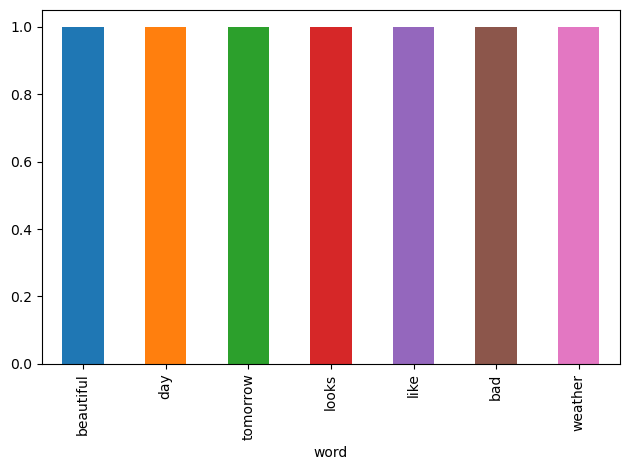

In [34]:
stop_words= stopwords.words('english')
items = blob.word_counts.items()
items = [item for item in items if item[0] not in stop_words]
from operator import itemgetter
sorted_items = sorted(items, key= lambda x: x[1], reverse=True)
top20 = sorted_items[1:21]
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
df = pd.DataFrame(top20, columns=['word','count'])
colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']
axes = df.plot.bar(x='word',y='count',legend=False,color=colors)
plt.gcf().tight_layout()

In [35]:
!pip install WordCloud

Defaulting to user installation because normal site-packages is not writeable


In [38]:
import sys
!{sys.executable} -m pip install imageio

In [6]:
text = TextBlob(Path('RomeoAndJuliet.txt').read_text())
text = text.raw
import imageio.v2 as imageio
mask_image = imageio.imread('heart.png')
from wordcloud import WordCloud
wordcloud = WordCloud(colormap='prism', mask = mask_image, background_color='white')
wordcloud = wordcloud.generate(text)
wordcloud = wordcloud.to_file('mask_heart.png')
get_ipython().run_line_magic('matplotlib','')
import matplotlib.pyplot as mat
mat.figure(figsize=(10,10))
mat.imshow(wordcloud)

Using matplotlib backend: <object object at 0x71c3e4a48ac0>
